<a href="https://colab.research.google.com/github/NathanEsser/ilhas-de-calor-blumenau/blob/main/ilhas_de_calor_blumenau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1 · Instalação (!pip install -q geobr)

Instala o geobr, um pacote do Ipea que baixa os mapas oficiais do IBGE, como municípios e bairros. O Colab já vem com quase tudo pronto, só esse precisa ser instalado. O -q deixa a instalação sem encher a tela de mensagens.

In [3]:
!pip install -q geobr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 55.4 MB/s eta 0:00:00


2 · Bibliotecas, Drive e função de checagem (import ee, geemap, geobr)

Carrega as bibliotecas do projeto e conecta o Google Drive, porque o Colab apaga tudo quando a sessão fecha. Também cria a pasta dados, onde os resultados ficam salvos, e a função checar(), que uso em todas as partes para conferir se um resultado faz sentido: aparece ✅ quando passa no critério e ⚠️ quando não passa.

In [4]:
import ee, geemap, geobr
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

PASTA = Path('/content/drive/MyDrive/ilhas-de-calor-blumenau/dados')
PASTA.mkdir(parents=True, exist_ok=True)

def checar(condicao, mensagem):
    """Mostra ✅ se a condição for verdadeira, ⚠️ se não for."""
    print(f"{'✅ OK' if condicao else '⚠️ ALERTA'}: {mensagem}")
    return condicao

Mounted at /content/drive


3 · Login no Earth Engine (PROJETO_EE = ...)

Faz o login no Google Earth Engine e informa em qual projeto vou trabalhar. O Earth Engine guarda o arquivo completo de imagens do Landsat nos servidores do Google, então eu não baixo nenhuma imagem para o Colab. Em vez disso, monto uma lista de instruções (recortar Blumenau, filtrar os verões, tirar as nuvens, calcular a mediana), e nada acontece enquanto estou escrevendo. Só quando peço um resultado, com o .getInfo(), ele executa tudo lá e me devolve apenas a resposta, como um número ou uma tabela. É por isso que dá para trabalhar com 64 imagens de satélite sem precisar de um computador potente.

In [5]:
PROJETO_EE = 'ilhas-calor-blumenau'  #Variável do nome do projeto criado no Google Earth Engine

ee.Authenticate() #Login na plataforma do Google Earth
ee.Initialize(project=PROJETO_EE) #Informa em qual projeto vamos atuar
print("Earth Engine inicializado no projeto:", PROJETO_EE)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine inicializado no projeto: ilhas-calor-blumenau


4 · Teste de conexão (ponto_blumenau = ...)

Teste rápido para ver se a conexão funcionou: marco um ponto no centro de Blumenau e conto quantas imagens do Landsat 9 passam por ele. O Earth Engine só calcula de verdade no .getInfo(), como ja mencionado. Antes disso é só um pedido montado, como anotar o pedido no restaurante antes de entregar na cozinha. Deu 85 imagens, então está funcionando.

In [6]:
ponto_blumenau = ee.Geometry.Point([-49.066, -26.919])  # [longitude, latitude]

n_l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
        .filterBounds(ponto_blumenau)
        .size()
        .getInfo())

print("Imagens Landsat 9 sobre Blumenau:", n_l9)
checar(n_l9 > 0, "Earth Engine responde e encontra imagens Landsat 9 sobre Blumenau")

Imagens Landsat 9 sobre Blumenau: 85
✅ OK: Earth Engine responde e encontra imagens Landsat 9 sobre Blumenau


True

5 · Município e bairros (COD_BLUMENAU = 4202404)

Baixa o contorno do município e os bairros de Blumenau usando o geobr. O geobr é um pacote criado pelo Ipea que reúne os mapas oficiais do Brasil, a maioria do IBGE, já organizados e prontos para usar em Python. Cada tipo de mapa tem sua função: read_municipality() traz municípios, read_neighborhood() traz bairros, e assim por diante. Quando chamo uma delas, o geobr baixa o arquivo e me entrega uma tabela em que cada linha é uma área (GeoDataFrame), com o nome e o desenho do contorno. A base de bairros vem com o Brasil inteiro, por isso filtro só as linhas com o código de Blumenau no IBGE (4202404).


Ex:
code_muni	name_neighborhood	...	geometry

4202404	Centro	...	MULTIPOLYGON (((-49.065 -26.924, ...)))

4202404	Vorstadt	...	MULTIPOLYGON (((-49.049 -26.920, ...)))

Como eu não sabia se a base de bairros de 2022 tinha Blumenau, deixei um plano B: tentar a de 2010 e, por último, os setores censitários. A de 2022 funcionou, e o plano B não foi usado.

In [7]:
COD_BLUMENAU = 4202404 #4202404 é o código IBGE de Blumenau. O 42 no início é o código de Santa Catarina.

municipio = geobr.read_municipality(code_muni=COD_BLUMENAU, year=2022, simplified=False)

# 2. Bairros, com plano B: 2022 → 2010 → setores censitários
def baixar_areas():
    for ano in [2022, 2010]:
        try:
            b = geobr.read_neighborhood(year=ano, simplified=False)
            b = b[b['code_muni'].astype(int) == COD_BLUMENAU]
            if len(b) > 0:
                return b, f'bairros IBGE {ano}'
            print(f'Bairros {ano}: base existe, mas não tem Blumenau')
        except Exception as e:
            print(f'Bairros {ano} indisponíveis: {e}')
    for ano in [2022, 2010]:
        try:
            s = geobr.read_census_tract(code_tract=COD_BLUMENAU, year=ano, simplified=False)
            if len(s) > 0:
                return s, f'setores censitários {ano}'
        except Exception as e:
            print(f'Setores {ano} indisponíveis: {e}')
    raise RuntimeError('Nenhuma base de áreas encontrada para Blumenau')

areas, FONTE_AREAS = baixar_areas()
print('Fonte usada:', FONTE_AREAS)
print('Colunas disponíveis:', list(areas.columns))

municipalities_2022.parquet: 100%|██████████| 269M/269M [00:07<00:00, 38.1MB/s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

neighborhoods_2022.parquet: 100%|██████████| 41.5M/41.5M [00:00<00:00, 43.7MB/s]


Fonte usada: bairros IBGE 2022
Colunas disponíveis: ['code_muni', 'name_muni', 'code_neighborhood', 'name_neighborhood', 'code_district', 'name_district', 'code_subdistrict', 'name_subdistrict', 'code_state', 'abbrev_state', 'name_state', 'code_region', 'name_region', 'year', 'geometry']


6 · Nome dos bairros e arquivo salvo (# 3. Padroniza o nome da área)

Cria a coluna nome_area com o nome de cada bairro e mantém só ela e o desenho do bairro (a geometria). Depois salva o município e os bairros em um único arquivo .gpkg no Drive, para não precisar baixar de novo.

In [8]:
# 3. Padroniza o nome da área (usa a primeira coluna de nome que existir)
candidatas = ['name_neighborhood', 'name_neighbo', 'name_district', 'code_tract']
coluna_nome = next(c for c in candidatas if c in areas.columns)
print('Coluna usada como nome:', coluna_nome)

areas = areas.copy()
areas['nome_area'] = areas[coluna_nome].astype(str).str.strip()
areas = areas[['nome_area', 'geometry']].reset_index(drop=True)

# 4. Salva tudo num único arquivo GeoPackage, com duas camadas
ARQ_AREAS = PASTA / 'area_estudo.gpkg'
municipio.to_file(ARQ_AREAS, layer='municipio', driver='GPKG')
areas.to_file(ARQ_AREAS, layer='areas', driver='GPKG')
print('Salvo em:', ARQ_AREAS)

Coluna usada como nome: name_neighborhood
Salvo em: /content/drive/MyDrive/ilhas-de-calor-blumenau/dados/area_estudo.gpkg


7 · Entendendo a geometria (print(areas.head(3)))

Célula de estudo, para ver o que tem dentro da tabela. A coluna geometry guarda o contorno de cada bairro como uma lista de coordenadas que, ligadas em ordem, formam o desenho. Os 35 bairros juntos somam mais de 26 mil pontos.

In [9]:
# Compreendendo a tablea gemotry - Basicamente retorna uma sequência de coordenadas dos bairros de blumenau, que quando ligados, formam o "desenho/polígono" de cada bairro
print(areas.head(3))

# O polígono do primeiro bairro, escrito como texto (só os primeiros caracteres)
print(areas['nome_area'].iloc[0])
print(areas.geometry.iloc[0].wkt[:300])

# Quantos pontos (vértices) formam todos os 35 bairros juntos
import shapely
print('Total de vértices:', shapely.get_num_coordinates(areas.geometry).sum())

         nome_area                                           geometry
0           Centro  MULTIPOLYGON (((-49.06556 -26.9245, -49.06582 ...
1         Vorstadt  MULTIPOLYGON (((-49.04962 -26.9207, -49.05133 ...
2  Ribeirão Fresco  MULTIPOLYGON (((-49.03652 -26.93104, -49.03659...
Centro
MULTIPOLYGON (((-49.065565 -26.924500499999997, -49.0658161 -26.9244471, -49.0659621 -26.924375, -49.0665212 -26.924190499999998, -49.0668429 -26.9241231, -49.0669567 -26.9241154, -49.06704949999999 -26.9241329, -49.0671598 -26.924187699999997, -49.067473799999995 -26.924270699999994, -49.0675646000
Total de vértices: 26577


8 · Área e mapa dos bairros (UTM = 31982)

Calcula a área do município e dos bairros. Para isso, troco as coordenadas de graus para metros (sistema UTM 22S), porque não dá para medir km² em graus. O município deu 518,7 km², quase igual aos 518,6 km² do IBGE, então o contorno está certo. O mapa mostra que os bairros ficam dentro da cidade e cobrem só a parte urbana, cerca de 40% da área.

Área do município: 518.7 km² (IBGE: ≈ 518,6)
Área coberta pelas 35 áreas: 207.5 km²


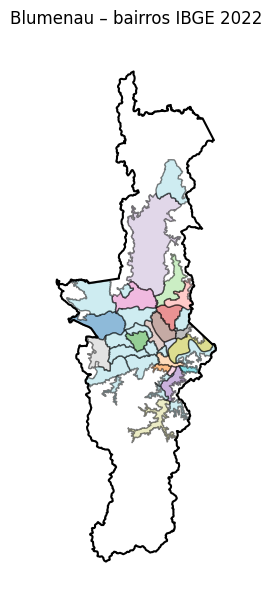

In [10]:
#Construção do mapa da cidade e da divisão dos bairros.
UTM = 31982  # SIRGAS 2000 / UTM 22S, em metros

area_mun_km2 = municipio.to_crs(UTM).area.sum() / 1e6
area_areas_km2 = areas.to_crs(UTM).area.sum() / 1e6
print(f'Área do município: {area_mun_km2:.1f} km² (IBGE: ≈ 518,6)')
print(f'Área coberta pelas {len(areas)} áreas: {area_areas_km2:.1f} km²')

# Checagem visual: os bairros devem ficar dentro do contorno do município
ax = municipio.to_crs(UTM).boundary.plot(color='black', figsize=(7, 7))
areas.to_crs(UTM).plot(ax=ax, column='nome_area', alpha=0.5, edgecolor='black')
ax.set_title(f'Blumenau – {FONTE_AREAS}')
ax.set_axis_off()

9 · Como o desenho funciona (bairro = areas.to_crs(UTM).explode(...))

Outra célula de estudo: pego o bairro Centro e desenho os pontos do contorno (em vermelho) e as linhas que ligam esses pontos (em preto). O primeiro e o último ponto são iguais, e é isso que "fecha" o polígono.

Centro - 376 pontos
Primeiro ponto: (692075.0208639164, 7020458.38109014)
Último ponto:   (692075.0208639164, 7020458.38109014)


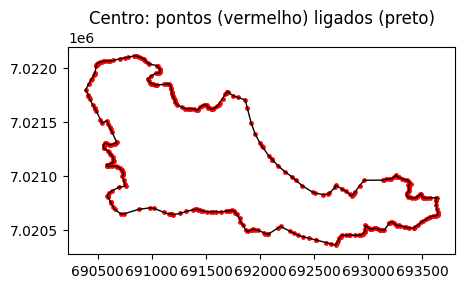

In [11]:
# Compreendendo como que funciona o desenho.
# Separa bairros com vários pedaços em polígonos individuais e pega o primeiro
bairro = areas.to_crs(UTM).explode(index_parts=False).iloc[0]

# .exterior = contorno externo; .xy = listas de coordenadas X e Y dos vértices
x, y = bairro.geometry.exterior.xy
print(bairro['nome_area'], '-', len(x), 'pontos')
print('Primeiro ponto:', (x[0], y[0]))
print('Último ponto:  ', (x[-1], y[-1]))   # Verfiicar se é igual ao primeiro: o polígono fecha

plt.figure(figsize=(5, 5))
plt.plot(x, y, color='black', linewidth=1)    # liga os pontos em ordem
plt.scatter(x, y, s=6, color='red')           # mostra os pontos em si
plt.gca().set_aspect('equal')                 # mesma escala em X e Y, sem distorcer
plt.title(f"{bairro['nome_area']}: pontos (vermelho) ligados (preto)")
plt.show()

10 · Parte 4 · Seleção das imagens (VERAO_INICIO = '2022-12-01')

Define o período dos verões (dezembro de 2022 a março de 2026) e o limite de 60% de nuvem por imagem. Antes de mandar o contorno da cidade para o Earth Engine, eu simplifico ele de 10.170 para 1.538 pontos.

1 · Simplificar o contorno

O contorno de Blumenau é feito de pontos ligados por linhas, como você viu na célula 9 com o Centro. O do município tem 10.170 pontos, muitos deles bem próximos, desenhando cada curvinha do limite.

Para o Earth Engine saber onde recortar, o código precisa mandar esse contorno junto com o pedido. Com 10.170 pontos o pedido ficava grande demais e o Earth Engine recusava, por isso o erro de tamanho.

O simplify(10) tira pontos com uma regra: o novo contorno nunca pode se afastar mais de 10 m do original. Num trecho quase reto, por exemplo, dez pontos podem virar dois, porque uma linha reta entre eles fica a menos de 10 m do traçado verdadeiro. Assim, de 10.170 pontos sobram 1.538.

Isso não muda o resultado porque o pixel do Landsat tem 30 m de lado. Se a borda da cidade se mexer no máximo 10 m, ela continua cortando praticamente os mesmos pixels. É como contornar um desenho com um lápis mais grosso: perde detalhe fino, mas a forma continua a mesma na escala que importa.

2 · A função filtrar()

O Landsat 8 e o Landsat 9 ficam em duas coleções separadas no Earth Engine. Em vez de escrever os mesmos filtros duas vezes, criei uma função, como uma receita: recebe o nome da coleção e aplica os quatro filtros (só Blumenau, só as datas do estudo, só dezembro a março e só cenas com menos de 60% de nuvem). Uso a receita uma vez para cada satélite e depois junto as duas pilhas de imagens em uma só com o merge.

In [12]:
# Parte 4 · Faça
VERAO_INICIO = '2022-12-01'
VERAO_FIM    = '2026-04-01'   # a data final não entra: vai até 31/03/2026
NUVEM_MAX    = 60

# Simplifica o contorno em metros (UTM) e volta para graus (EPSG:4326)
mun_leve = municipio[['geometry']].to_crs(UTM)
mun_leve['geometry'] = mun_leve.geometry.simplify(10)
mun_leve = mun_leve.to_crs(epsg=4326)
print('Vértices antes:', shapely.get_num_coordinates(municipio.geometry).sum(),
      '| depois:', shapely.get_num_coordinates(mun_leve.geometry).sum())

area_ee = geemap.gdf_to_ee(mun_leve)
regiao = area_ee.geometry()

#Criada uma função porque vamos aplicar exatamente os mesmos filtros a dois satélites. Assim, as regras são escritas uma vez só.
# filterBounds(regiao)	Só fotos que cobrem Blumenau
# filterDate(...)	Só fotos de dez/2022 a mar/2026
# calendarRange(12, 3, 'month')	Só fotos de dez, jan, fev e mar (tira os invernos do meio)
# lt('CLOUD_COVER', 60)	Só fotos com menos de 60% de nuvem (lt = less than, menor que)
def filtrar(colecao_id):
    return (ee.ImageCollection(colecao_id)
            .filterBounds(regiao)
            .filterDate(VERAO_INICIO, VERAO_FIM)
            .filter(ee.Filter.calendarRange(12, 3, 'month'))
            .filter(ee.Filter.lt('CLOUD_COVER', NUVEM_MAX)))

l8 = filtrar('LANDSAT/LC08/C02/T1_L2')
l9 = filtrar('LANDSAT/LC09/C02/T1_L2')
imagens = l8.merge(l9).sort('system:time_start')

# print(imagens)   # ainda é só uma instrução: nada foi calculado

Vértices antes: 10170 | depois: 1538


11 · Parte 4 · Conferência das imagens (props = ee.Dictionary(...))

Pede ao Earth Engine a data, o satélite e a nuvem de cada imagem e monta uma tabela por verão. Dezembro conta como parte do verão seguinte: dezembro de 2022 entra no verão 2022/23. No fim confiro se todas as imagens são de dezembro a março, se nenhuma passa de 60% de nuvem e se os dois satélites aparecem. Foram 64 imagens.

In [13]:
# Parte 4 · Valide
import pandas as pd

props = ee.Dictionary({
    'data':     imagens.aggregate_array('DATE_ACQUIRED'),
    'satelite': imagens.aggregate_array('SPACECRAFT_ID'),
    'nuvem':    imagens.aggregate_array('CLOUD_COVER'),
}).getInfo()   # aqui o Earth Engine calcula de verdade

df = pd.DataFrame(props)
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.month

# Dezembro pertence ao verão do ano seguinte (dez/2022 → verão 2022/23)
def verao(d):
    ano = d.year if d.month == 12 else d.year - 1
    return f"{ano}/{str(ano + 1)[-2:]}"
df['verao'] = df['data'].apply(verao)

print(df.groupby(['verao', 'satelite']).size().unstack(fill_value=0))
print(f"\nTotal: {len(df)} imagens")

checar(len(df) >= 5, f"{len(df)} imagens (mínimo: 5)")
checar(df['mes'].isin([12, 1, 2, 3]).all(), "todas as imagens são de dezembro a março")
checar(df['nuvem'].max() < NUVEM_MAX, "nenhuma cena acima de 60% de nuvem")
checar(df['satelite'].nunique() == 2, "Landsat 8 e 9 presentes")

satelite  LANDSAT_8  LANDSAT_9
verao                         
2022/23           6          7
2023/24          10          8
2024/25           5          9
2025/26          10          9

Total: 64 imagens
✅ OK: 64 imagens (mínimo: 5)
✅ OK: todas as imagens são de dezembro a março
✅ OK: nenhuma cena acima de 60% de nuvem
✅ OK: Landsat 8 e 9 presentes


True

12 · Parte 5 · Lendo os bits da QA_PIXEL (for valor in [21824, 22280])

Aqui é importante entender O que é a QA_PIXEL

Cada pixel da imagem do Landsat vem com várias "bandas": uma com a temperatura, outras com as cores, e uma chamada QA_PIXEL, que é uma ficha de qualidade do pixel. Essa ficha responde a perguntas de sim ou não: tem nuvem? tem sombra de nuvem? é água? é neve?

Em vez de guardar cada resposta separada, o USGS guarda todas juntas em um número só, como 21824. Como um número guarda várias respostas, o computador escreve números em binário, só com 0 e 1. O número 21824, em binário, fica assim:

0101010101000000

São 16 posições, e cada uma funciona como um quadradinho de formulário: 1 é "sim", 0 é "não". O USGS definiu o que cada posição significa. As posições são contadas da direita para a esquerda, começando do zero. As que importam aqui:


1.   posição 1: borda de nuvem
2.   posição 3: nuvem
3.   posição 4: sombra de nuvem

Os dois valores testados

*   21824 → 0101010101000000   (posições 1, 3 e 4 = 0)
*   22280 → 0101011100001000   (posição 3 = 1)

Contando da direita: no 21824 as posições 1, 3 e 4 estão todas em 0, então é um pixel limpo. No 22280, a quarta casa da direita (posição 3) está em 1, então esse pixel é nuvem.

O que o código faz:

O trecho (valor >> 3) & 1 é só um jeito de ler uma posição. O >> 3 empurra o número 3 casas para a direita, e o & 1 olha apenas o último dígito. O resultado é 0 ou 1: a resposta daquela pergunta.

Essa célula é um teste com dois números para entender a lógica. Na célula seguinte, a função remover_nuvens() faz a mesma leitura em todos os pixels da imagem de uma vez e apaga os que têm 1 em qualquer uma das três posições.

In [14]:
# Parte 5 · Aquecimento: lendo bits da QA_PIXEL
for valor in [21824, 22280]:
    print(valor, '→', format(valor, '016b'),
          '| bit 1:', (valor >> 1) & 1,
          '| bit 3:', (valor >> 3) & 1,
          '| bit 4:', (valor >> 4) & 1)

21824 → 0101010101000000 | bit 1: 0 | bit 3: 0 | bit 4: 0
22280 → 0101011100001000 | bit 1: 0 | bit 3: 1 | bit 4: 0


13 · Parte 5 · Funções de nuvem e conversão (def remover_nuvens(img))

As duas funções principais do projeto. remover_nuvens() apaga os pixels com nuvem, borda de nuvem ou sombra, porque nuvem é fria e faria um bairro parecer mais fresco do que é. converter() usa as fórmulas oficiais do USGS para transformar os números brutos do satélite em temperatura (°C) e em NDVI, o índice de vegetação.

In [15]:
# Parte 5 · Faça
def remover_nuvens(img):
    """Apaga (mascara) pixels de nuvem, borda de nuvem e sombra."""
    qa = img.select('QA_PIXEL')
    nuvem = (qa.bitwiseAnd(1 << 1).neq(0)          # bit 1: nuvem dilatada (borda)
             .Or(qa.bitwiseAnd(1 << 3).neq(0))     # bit 3: nuvem
             .Or(qa.bitwiseAnd(1 << 4).neq(0)))    # bit 4: sombra de nuvem
    return img.updateMask(nuvem.Not())             # mantém só onde NÃO é nuvem

def converter(img):
    """Transforma números brutos em temperatura (°C) e NDVI."""
    temp_c = (img.select('ST_B10')
                 .multiply(0.00341802).add(149.0)  # → Kelvin
                 .subtract(273.15)                 # → °C
                 .rename('temp_c'))
    refl = img.select(['SR_B4', 'SR_B5']).multiply(0.0000275).add(-0.2)  # → reflectância
    ndvi = refl.normalizedDifference(['SR_B5', 'SR_B4']).rename('ndvi')   # (B5−B4)/(B5+B4)
    return img.addBands(temp_c).addBands(ndvi).select(['temp_c', 'ndvi'])

14 · Parte 5 · Teste em uma imagem (teste_bruta = imagens.sort(...))

Antes de aplicar as funções em tudo, testo em uma imagem só, a que tem menos nuvem: 20/03/2023, do Landsat 9.

In [16]:
# Parte 5 · Teste em uma imagem
teste_bruta = imagens.sort('CLOUD_COVER').first()
teste = converter(remover_nuvens(teste_bruta))

info = ee.Dictionary({
    'data':       teste_bruta.get('DATE_ACQUIRED'),
    'satelite':   teste_bruta.get('SPACECRAFT_ID'),
    'nuvem_cena': teste_bruta.get('CLOUD_COVER'),
}).getInfo()
print('Imagem de teste:', info)

Imagem de teste: {'data': '2023-03-20', 'nuvem_cena': 0.53, 'satelite': 'LANDSAT_9'}


15 · Parte 5 · Conferência do teste (redutor = ee.Reducer.percentile(...))

Calcula mínimo, máximo e alguns percentis da temperatura e do NDVI nessa imagem. A mediana deu 32,9 °C e o NDVI ficou entre −1 e 1, então a conversão funcionou. O texto abaixo comenta os valores extremos.

In [17]:
# Parte 5 · Valide
redutor = ee.Reducer.percentile([5, 50, 95]).combine(ee.Reducer.minMax(), sharedInputs=True)

stats = teste.reduceRegion(reducer=redutor, geometry=regiao,
                           scale=30, maxPixels=1e9).getInfo()

# Fração de Blumenau com dado válido nesta imagem (0 a 1)
validos = (teste.select('temp_c').mask()
           .reduceRegion(ee.Reducer.mean(), regiao, 30, maxPixels=1e9)
           .get('temp_c').getInfo())

print(f"Temperatura (°C): mín {stats['temp_c_min']:.1f} | p5 {stats['temp_c_p5']:.1f} | "
      f"mediana {stats['temp_c_p50']:.1f} | p95 {stats['temp_c_p95']:.1f} | máx {stats['temp_c_max']:.1f}")
print(f"NDVI:             mín {stats['ndvi_min']:.2f} | p5 {stats['ndvi_p5']:.2f} | "
      f"mediana {stats['ndvi_p50']:.2f} | p95 {stats['ndvi_p95']:.2f} | máx {stats['ndvi_max']:.2f}")
print(f"Área com dado válido: {validos:.0%}")

checar(15 <= stats['temp_c_p50'] <= 50, f"mediana da temperatura {stats['temp_c_p50']:.1f} °C (faixa 15–50)")
checar(stats['ndvi_min'] >= -1 and stats['ndvi_max'] <= 1, "NDVI entre −1 e 1")

Temperatura (°C): mín 25.4 | p5 29.4 | mediana 32.9 | p95 40.9 | máx 64.2
NDVI:             mín -0.95 | p5 0.35 | mediana 0.89 | p95 0.91 | máx 1.00
Área com dado válido: 100%
✅ OK: mediana da temperatura 32.9 °C (faixa 15–50)
✅ OK: NDVI entre −1 e 1


True

Lendo o resultado

Temperatura: mediana de 32,9 °C, dentro da faixa. A distribuição faz sentido: metade de Blumenau entre ~29 e ~41 °C (p5 a p95) numa manhã de verão.

Mínimo de 25,4 °C:Se uma nuvem tivesse escapado da máscara, apareceria um mínimo absurdo, perto de 0 °C ou negativo. O pixel mais frio estar em 25 °C, provavelmente rio ou mata densa, indica que nesta imagem a máscara funcionou. Com uma ressalva honesta: escolhemos a imagem com menos nuvem, então foi o teste mais fácil. A prova de fogo é o mapa da Parte 6, com todas as 64.

Máximo de 64,2 °C: Telhados metálicos e galpões industriais escuros chegam a temperaturas assim sob sol forte. O código demonstra a temperatura do material, não do ar. Como o p95 está em 40,9 °C, são pouquíssimos pixels.

NDVI: mediana de 0,89, confirmando que a maior parte do município é mata densa (≥ 0,6). O mínimo de −0,95 é água (o Itajaí-Açu).

NDVI máximo = 1,00 em poucos pixels, provável efeito de sombra de relevo; não afeta medianas.

16 · Parte 6 · Composição dos verões (colecao = imagens.map(...))

Aplica a remoção de nuvens e a conversão nas 64 imagens e, para cada pixel, pega a mediana, que é o valor do meio entre todas as observações. É como empilhar várias folhas transparentes do mesmo lugar e escolher, em cada ponto, o valor do meio. O resultado é um "verão típico". Também conto quantas observações limpas cada pixel teve e simplifico os bairros, como fiz com o município.

In [18]:
# Parte 6 · Faça (1/2): composição
colecao = imagens.map(remover_nuvens).map(converter)

composta = colecao.median().clip(regiao)                               # verão típico
n_obs = colecao.select('temp_c').count().rename('n_obs').clip(regiao)  # nº de valores válidos por pixel

# Bairros simplificados (mesma lógica do município) para desenhar no mapa e usar na Parte 7
bairros_leve = areas.to_crs(UTM)
bairros_leve['geometry'] = bairros_leve.geometry.simplify(10)
bairros_ee = geemap.gdf_to_ee(bairros_leve.to_crs(epsg=4326))

17 · Parte 6 · Conferência da composição (stats6 = ...)

Confere a imagem final: mediana de 29,9 °C no município e diferença de 13,2 °C entre p5 e p95, dentro do esperado. O alerta apareceu porque alguns pixels tiveram menos de 3 observações limpas, e a próxima célula investiga onde eles estão.

In [19]:
# Parte 6 · Valide
redutor = ee.Reducer.percentile([5, 50, 95]).combine(ee.Reducer.minMax(), sharedInputs=True)
stats6 = (composta.addBands(n_obs)
          .reduceRegion(reducer=redutor, geometry=regiao, scale=30, maxPixels=1e9)
          .getInfo())

p5, p50, p95 = stats6['temp_c_p5'], stats6['temp_c_p50'], stats6['temp_c_p95']
amplitude = p95 - p5

print(f"Temperatura (°C): mín {stats6['temp_c_min']:.1f} | p5 {p5:.1f} | mediana {p50:.1f} | "
      f"p95 {p95:.1f} | máx {stats6['temp_c_max']:.1f}")
print(f"NDVI mediano: {stats6['ndvi_p50']:.2f}")
print(f"Observações limpas por pixel: mín {stats6['n_obs_min']:.0f} | "
      f"mediana {stats6['n_obs_p50']:.0f} | máx {stats6['n_obs_max']:.0f}")

checar(p5 < p50 < p95, "percentis em ordem (p5 < p50 < p95)")
checar(3 <= amplitude <= 25, f"amplitude p5–p95 de {amplitude:.1f} °C (faixa 3–25)")
checar(stats6['n_obs_min'] >= 3, "todo pixel tem pelo menos 3 observações limpas")

Temperatura (°C): mín 23.6 | p5 26.4 | mediana 29.9 | p95 39.6 | máx 59.6
NDVI mediano: 0.89
Observações limpas por pixel: mín 1 | mediana 21 | máx 51
✅ OK: percentis em ordem (p5 < p50 < p95)
✅ OK: amplitude p5–p95 de 13.2 °C (faixa 3–25)
⚠️ ALERTA: todo pixel tem pelo menos 3 observações limpas


False

18 · Parte 6 · Onde faltam observações (poucos = n_obs.lt(5))

Mede quanto da cidade tem pixels com menos de 5 observações. Deu praticamente 0%, então são pixels isolados, provavelmente nas bordas, e não afetam o resultado.

In [20]:
# Parte 6 · Diagnóstico: onde faltam observações?
poucos = n_obs.lt(5).rename('poucos')   # 1 = pixel com menos de 5 observações

frac_mun = poucos.reduceRegion(ee.Reducer.mean(), regiao, 30, maxPixels=1e9).get('poucos')
frac_bairros = poucos.reduceRegion(ee.Reducer.mean(), bairros_ee.geometry(), 30, maxPixels=1e9).get('poucos')
fracs = ee.Dictionary({'municipio': frac_mun, 'bairros': frac_bairros}).getInfo()

print(f"Pixels com menos de 5 observações: {fracs['municipio']:.2%} do município | "
      f"{fracs['bairros']:.2%} da área dos bairros")

Pixels com menos de 5 observações: 0.00% do município | 0.00% da área dos bairros


19 · Parte 6 · Mapa interativo (vis_temp = {...})

Monta o mapa com a temperatura (azul para frio, vermelho para quente), o NDVI e o contorno dos bairros sobre uma foto de satélite. A escala de cores vai do p5 ao p95 para que poucos pixels muito quentes não tirem o contraste do resto do mapa. O mapa é salvo em HTML no Drive

In [21]:
# Parte 6 · Faça (2/2): mapa interativo
vis_temp = {'min': round(p5), 'max': round(p95),
            'palette': ['313695', '74add1', 'ffffbf', 'f46d43', 'a50026']}  # azul → vermelho
vis_ndvi = {'min': 0, 'max': 0.9, 'palette': ['a6611a', 'f5f5f5', '1a9641']}  # marrom → verde

m = geemap.Map(basemap='Esri.WorldImagery')   # fundo: foto de satélite (sem bloqueio)
m.addLayer(composta.select('ndvi'), vis_ndvi, 'NDVI (vegetação)', False)
m.addLayer(n_obs, {'min': 0, 'max': 40, 'palette': ['ffffff', '54278f']}, 'Nº de observações limpas', False)
m.addLayer(composta.select('temp_c'), vis_temp, 'Temperatura de superfície (°C)')
m.addLayer(ee.Image().paint(bairros_ee, 0, 1), {'palette': ['000000']}, 'Bairros (IBGE 2022)')
m.add_colorbar(vis_temp, label='Temperatura de superfície (°C) · mediana dos verões 2022/23–2025/26')

ARQ_MAPA = PASTA / 'mapa_calor_verao.html'
m.to_html(str(ARQ_MAPA))
print('Mapa salvo em:', ARQ_MAPA)
m

Mapa salvo em: /content/drive/MyDrive/ilhas-de-calor-blumenau/dados/mapa_calor_verao.html


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

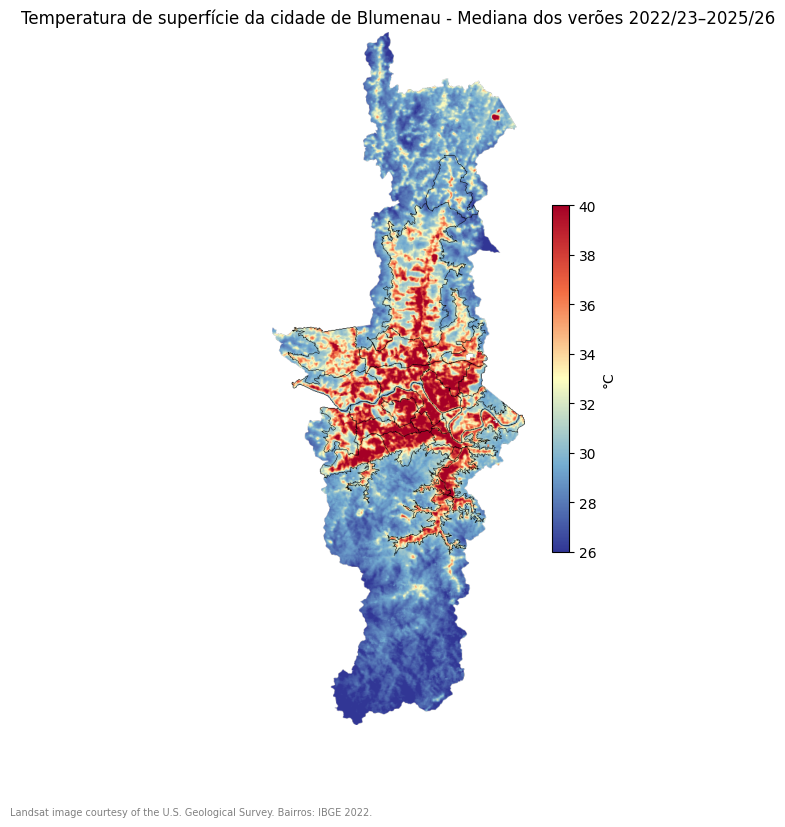

In [28]:
# Parte 6 · Mapa estático (PNG que aparece no GitHub e não expira)
import requests
from matplotlib.colors import LinearSegmentedColormap

# Temperatura colorida + contorno dos bairros em preto
contorno = ee.Image().paint(bairros_ee, 0, 1).visualize(palette=['000000'])
mapa_img = composta.select('temp_c').visualize(**vis_temp).blend(contorno)

# Pede a "foto" ao Earth Engine e salva no Drive
url = mapa_img.getThumbURL({'region': regiao, 'dimensions': 1200, 'format': 'png'})
ARQ_PNG = PASTA / 'mapa_calor_verao.png'
ARQ_PNG.write_bytes(requests.get(url).content)

# Mostra com legenda de cores
cores = LinearSegmentedColormap.from_list('temp', ['#' + c for c in vis_temp['palette']])
escala = plt.cm.ScalarMappable(cmap=cores, norm=plt.Normalize(vis_temp['min'], vis_temp['max']))

fig, ax = plt.subplots(figsize=(7, 9))
ax.imshow(plt.imread(ARQ_PNG))
ax.axis('off')
ax.set_title('Temperatura de superfície da cidade de Blumenau - Mediana dos verões 2022/23–2025/26')
fig.colorbar(escala, ax=ax, shrink=0.5, label='°C')
fig.text(0.01, 0.01, 'Landsat image courtesy of the U.S. Geological Survey. Bairros: IBGE 2022.',
         fontsize=7, color='gray')
plt.savefig(PASTA / 'mapa_calor_verao_legenda.png', dpi=200, bbox_inches='tight')
plt.show()

20 · Parte 7 · Média por bairro e ranking (redutor_bairro = ...)

Calcula a temperatura média e o NDVI médio dentro de cada bairro, além de quantos pixels cada um tem. Assim o mapa vira uma tabela, e ordenando do mais quente para o mais frio sai o ranking. Salvo em CSV, que abre no Excel, e em .gpkg, que guarda também os contornos.

In [22]:
# Parte 7 · Faça
# Média e contagem de pixels de cada banda, dentro de cada bairro
redutor_bairro = ee.Reducer.mean().combine(ee.Reducer.count(), sharedInputs=True)
por_bairro = composta.reduceRegions(collection=bairros_ee, reducer=redutor_bairro, scale=30)

# Traz só a tabela (sem os contornos, que já temos no Python)
colunas = ['nome_area', 'temp_c_mean', 'ndvi_mean', 'temp_c_count']
dados = por_bairro.select(colunas, None, False).getInfo()

tabela = pd.DataFrame([f['properties'] for f in dados['features']])
tabela = tabela.rename(columns={'temp_c_mean': 'temp_media',
                                'ndvi_mean': 'ndvi_medio',
                                'temp_c_count': 'n_pixels'})

# Diferença em relação à média entre os bairros
media_bairros = tabela['temp_media'].mean()
tabela['dif_media'] = tabela['temp_media'] - media_bairros

# Ranking: 1 = mais quente
ranking = tabela.sort_values('temp_media', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1
print(ranking[['nome_area', 'temp_media', 'dif_media', 'ndvi_medio', 'n_pixels']].round(2).to_string())

# Salva: CSV (Excel) e GeoPackage (com contornos)
ranking.to_csv(PASTA / 'ranking_bairros.csv', index_label='posicao', encoding='utf-8-sig')
bairros_resultado = areas.merge(tabela, on='nome_area')
bairros_resultado.to_file(PASTA / 'bairros_resultado.gpkg', layer='bairros', driver='GPKG')
print('\nSalvo em:', PASTA)

           nome_area  temp_media  dif_media  ndvi_medio  n_pixels
1          Vila Nova       39.51       4.09        0.47      2528
2     Itoupava Norte       39.08       3.66        0.45      7218
3         Água Verde       38.21       2.79        0.57      6493
4      Victor Konder       37.83       2.41        0.50      1111
5      Itoupava Seca       37.57       2.15        0.47      3855
6             Centro       37.45       2.03        0.50      3180
7    Escola Agrícola       37.40       1.98        0.61      5166
8          Fortaleza       37.34       1.92        0.58      6608
9    Jardim Blumenau       37.29       1.87        0.48       885
10            Garcia       37.08       1.66        0.57      6094
11             Velha       37.00       1.58        0.60      8114
12          do Salto       36.73       1.31        0.51      3336
13    Salto do Norte       36.45       1.03        0.55      9369
14        Valparaíso       36.19       0.77        0.63      2052
15     Vel

### Parte 7 · Leitura dos resultados

**H1 confirmada.** A temperatura média de superfície varia bastante entre os bairros de Blumenau no verão:

- **Entre os bairros urbanos:** 6,5 °C de diferença, de Vila Nova (39,5 °C, o mais quente) a Ribeirão Fresco (33,1 °C).
- **Incluindo Vila Itoupava:** 9,5 °C. Vila Itoupava (30,1 °C, NDVI 0,83) fica 3 °C abaixo do penúltimo colocado. Ela tem perfil essencialmente rural e de mata, e não deve ser apresentada como "bairro urbano mais fresco".

**Média entre bairros:** 35,4 °C, contra 29,9 °C de mediana no município inteiro. A área urbana é cerca de 5 °C mais quente que o entorno de mata e área rural.

**Prévia da H2.** Os bairros mais quentes têm NDVI entre 0,45 e 0,50, e os mais frios, acima de 0,70. Há exceções que indicam outros fatores além da vegetação (rio, relevo, tipo de construção):

- Boa Vista (NDVI 0,53) e Vorstadt (0,56) estão na metade fria do ranking.
- Escola Agrícola (NDVI 0,61) está entre os mais quentes (7º lugar).

**Cuidados.**

- A média de cada bairro inclui tudo o que está dentro dele, inclusive morros com mata. Bairros grandes e com muita vegetação tendem a ter média mais baixa, mesmo que a parte habitada seja quente.
- A média entre bairros é simples, sem peso pela área de cada um.
- Temperatura de superfície medida às 10h, não temperatura do ar.

**Arquivos gerados:** `ranking_bairros.csv` e `bairros_resultado.gpkg`, na pasta `dados` do Drive.

21 · Parte 7 · Teste do rio (agua = composta.select('ndvi').lt(0))

Testa a hipótese de que o rio estava distorcendo as médias. Marco como água os pixels com NDVI negativo, tiro esses pixels e recalculo a temperatura e o NDVI de cada bairro. Também calculo quanto de cada bairro é água. A tabela mostra os 10 bairros com mais água.

In [23]:
# Parte 7 · Teste de hipótese: o rio distorce a média dos bairros?
agua = composta.select('ndvi').lt(0).rename('frac_agua')   # 1 = água, 0 = terra
terra = composta.updateMask(agua.Not()).rename(['temp_terra', 'ndvi_terra'])

res = terra.addBands(agua).reduceRegions(collection=bairros_ee,
                                         reducer=ee.Reducer.mean(), scale=30)
d2 = res.select(['nome_area', 'temp_terra', 'ndvi_terra', 'frac_agua'], None, False).getInfo()

comp = tabela.merge(pd.DataFrame([f['properties'] for f in d2['features']]), on='nome_area')
print(comp.sort_values('frac_agua', ascending=False)
          [['nome_area', 'frac_agua', 'temp_media', 'temp_terra', 'ndvi_medio', 'ndvi_terra']]
          .head(10).round(2).to_string())

          nome_area  frac_agua  temp_media  temp_terra  ndvi_medio  ndvi_terra
11        Boa Vista       0.14       33.98       34.49        0.53        0.69
1          Vorstadt       0.09       33.95       34.29        0.56        0.66
18         do Salto       0.07       36.73       37.25        0.51        0.59
20      Ponta Aguda       0.07       33.88       34.14        0.60        0.68
19    Itoupava Seca       0.07       37.57       38.05        0.47        0.53
15  Salto Weissbach       0.06       35.11       35.45        0.59        0.65
26        Badenfurt       0.05       34.27       34.49        0.64        0.69
25   Salto do Norte       0.04       36.45       36.72        0.55        0.59
22   Itoupava Norte       0.03       39.08       39.33        0.45        0.48
0            Centro       0.03       37.45       37.58        0.50        0.52


### Parte 7 · Teste: o rio distorce as médias?

**Hipótese** (a partir da observação do mapa): Boa Vista e Vorstadt parecem fugir do padrão (pouca vegetação, mas frios) porque incluem trechos do Itajaí-Açu. A água é fria e tem NDVI negativo, então baixa ao mesmo tempo a temperatura e o NDVI médio do bairro.

**Teste:** pixels com NDVI < 0 foram classificados como água e removidos, e as médias foram recalculadas.

**Resultado: hipótese confirmada.** Boa Vista (14% de água) e Vorstadt (9%) são os bairros com mais água. Sem ela, o NDVI de Boa Vista sobe de 0,53 para 0,69, e o de Vorstadt, de 0,56 para 0,66. Os dois passam a seguir o padrão "mais verde, mais frio". O topo do ranking não se altera.

**Decisão:** a Parte 8 usa as médias sem água (`temp_terra`, `ndvi_terra`), porque a H2 compara vegetação com área construída, e a água é uma terceira categoria.

**Limitação:** o Itajaí-Açu é barrento, e água turva pode ter NDVI levemente positivo. Parte do rio pode não ter sido removida.

**Pendente:** Escola Agrícola (NDVI 0,61, 7º mais quente). Hipóteses: predomínio de pasto ou gramado em vez de mata (o NDVI não distingue os dois), ou encostas voltadas para o sol da manhã.

22 · Parte 7b · Ranking sem água (ranking_terra = ...)

Refaz o ranking usando as médias sem água e compara com a posição antiga, para ver quais bairros subiram ou desceram. No fim, recalcula a diferença entre o bairro urbano mais quente e o mais fresco, e a média entre os bairros.

In [24]:
# Parte 7b · Ranking sem água
ranking_terra = (comp[['nome_area', 'temp_terra', 'ndvi_terra', 'frac_agua']]
                 .sort_values('temp_terra', ascending=False)
                 .reset_index(drop=True))
ranking_terra.index = ranking_terra.index + 1   # posição começa em 1

# Compara com a posição antiga (com água)
pos_antiga = {nome: i + 1 for i, nome in enumerate(ranking['nome_area'])}
ranking_terra['pos_com_agua'] = ranking_terra['nome_area'].map(pos_antiga)
ranking_terra['subiu'] = ranking_terra['pos_com_agua'] - ranking_terra.index

print(ranking_terra.round(2).to_string())

# Números da H1 recalculados
urbanos = ranking_terra[ranking_terra['nome_area'] != 'Vila Itoupava']
print(f"\nAmplitude entre bairros urbanos: {urbanos['temp_terra'].max() - urbanos['temp_terra'].min():.1f} °C")
print(f"Média entre bairros: {ranking_terra['temp_terra'].mean():.1f} °C")

           nome_area  temp_terra  ndvi_terra  frac_agua  pos_com_agua  subiu
1          Vila Nova       39.51        0.47       0.00             1      0
2     Itoupava Norte       39.33        0.48       0.03             2      0
3         Água Verde       38.21        0.57       0.00             3      0
4      Itoupava Seca       38.05        0.53       0.07             5      1
5      Victor Konder       37.83        0.50       0.00             4     -1
6             Centro       37.58        0.52       0.03             6      0
7    Escola Agrícola       37.40        0.61       0.00             7      0
8          Fortaleza       37.34        0.58       0.00             8      0
9    Jardim Blumenau       37.29        0.48       0.00             9      0
10          do Salto       37.25        0.59       0.07            12      2
11            Garcia       37.07        0.57       0.00            10     -1
12             Velha       37.00        0.60       0.00            11     -1

23 · Parte 8 · Vegetação × temperatura (from scipy import stats)

Mede a relação entre vegetação e temperatura com uma regressão linear: uma reta que passa o mais perto possível de todos os bairros. Dela saem o r e o R², que mostram o quanto os pontos seguem a reta, e quantos graus a temperatura muda a cada +0,1 de NDVI. Faço a mesma conta sem a Vila Itoupava, para ver se o resultado depende dela. No gráfico, cada ponto é um bairro.

Todos os 35 bairros  : r = -0.95 | R² = 0.91 | -2.13 °C por +0,1 de NDVI | p = 0.0000
Sem Vila Itoupava (34): r = -0.95 | R² = 0.91 | -2.02 °C por +0,1 de NDVI | p = 0.0000


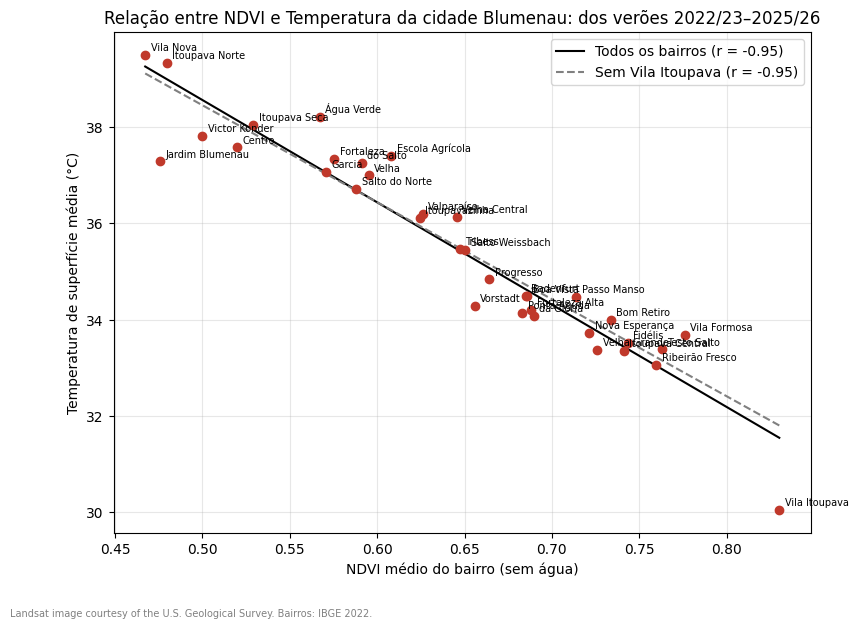

In [25]:
# Parte 8 · Faça
from scipy import stats

dados8 = comp[['nome_area', 'temp_terra', 'ndvi_terra']].copy()
dados8.to_csv(PASTA / 'bairros_sem_agua.csv', index=False, encoding='utf-8-sig')

todos  = stats.linregress(dados8['ndvi_terra'], dados8['temp_terra'])
sem_vi = stats.linregress(dados8.loc[dados8['nome_area'] != 'Vila Itoupava', 'ndvi_terra'],
                          dados8.loc[dados8['nome_area'] != 'Vila Itoupava', 'temp_terra'])

for nome, r in [('Todos os 35 bairros  ', todos), ('Sem Vila Itoupava (34)', sem_vi)]:
    print(f"{nome}: r = {r.rvalue:.2f} | R² = {r.rvalue**2:.2f} | "
          f"{r.slope / 10:+.2f} °C por +0,1 de NDVI | p = {r.pvalue:.4f}")

# Gráfico de dispersão: cada ponto é um bairro
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(dados8['ndvi_terra'], dados8['temp_terra'], color='#c0392b', zorder=3)
for _, linha in dados8.iterrows():
    ax.annotate(linha['nome_area'], (linha['ndvi_terra'], linha['temp_terra']),
                fontsize=7, xytext=(4, 3), textcoords='offset points')

x = np.linspace(dados8['ndvi_terra'].min(), dados8['ndvi_terra'].max(), 50)
ax.plot(x, todos.intercept + todos.slope * x, color='black',
        label=f'Todos os bairros (r = {todos.rvalue:.2f})')
ax.plot(x, sem_vi.intercept + sem_vi.slope * x, color='gray', linestyle='--',
        label=f'Sem Vila Itoupava (r = {sem_vi.rvalue:.2f})')

ax.set_xlabel('NDVI médio do bairro (sem água)')
ax.set_ylabel('Temperatura de superfície média (°C)')
ax.set_title('Relação entre NDVI e Temperatura da cidade Blumenau: dos verões 2022/23–2025/26')
ax.legend()
ax.grid(alpha=0.3)
fig.text(0.01, -0.02, 'Landsat image courtesy of the U.S. Geological Survey. Bairros: IBGE 2022.',
         fontsize=7, color='gray')

plt.savefig(PASTA / 'dispersao_temp_ndvi.png', dpi=200, bbox_inches='tight')
plt.show()

In [26]:
# Parte 8 · Valide
checar(todos.rvalue < 0, "correlação negativa (mais verde, mais frio)")
checar(abs(todos.rvalue) > 0.3, f"|r| = {abs(todos.rvalue):.2f} (mínimo 0,3)")
checar(sem_vi.rvalue < 0 and abs(sem_vi.rvalue) > 0.3,
       "relação se mantém sem Vila Itoupava (resultado robusto)")
checar(todos.pvalue < 0.05, f"p = {todos.pvalue:.4f} (abaixo de 0,05)");

✅ OK: correlação negativa (mais verde, mais frio)
✅ OK: |r| = 0.95 (mínimo 0,3)
✅ OK: relação se mantém sem Vila Itoupava (resultado robusto)
✅ OK: p = 0.0000 (abaixo de 0,05)


### Parte 8 · Leitura dos resultados

**H2 confirmada.** Bairros com mais vegetação têm superfície mais fria.

| Análise | r | R² | Efeito de +0,1 de NDVI |
|---|---|---|---|
| Todos os 35 bairros | −0,95 | 0,91 | −2,13 °C |
| Sem Vila Itoupava (34) | −0,95 | 0,91 | −2,02 °C |

- **Número de impacto:** cada +0,1 de NDVI está associado a cerca de **2 °C a menos** na temperatura média de superfície do bairro.
- **Quanto a vegetação explica:** a diferença de vegetação acompanha cerca de 90% da diferença de temperatura entre os bairros.
- **Robustez:** retirar Vila Itoupava (ponto extremo, perfil rural) praticamente não altera o resultado.
- **Conferência:** entre Vila Nova e Ribeirão Fresco (0,29 de diferença de NDVI), a reta prevê ~6,2 °C. Observado: 6,5 °C.

**Bairros fora da reta** (sinal de outros fatores):

- **Escola Agrícola:** ~1 °C acima do esperado. Hipóteses: pasto ou gramado em vez de mata; encostas voltadas para o sol da manhã.
- **Jardim Blumenau:** ~1,8 °C abaixo do esperado, o maior desvio. Causa a investigar.

**Cuidados de interpretação.**

- **Associação, não causa.** Bairros com menos vegetação também têm mais asfalto, telhados e concreto. O NDVI funciona como indicador de quanto do bairro é natural e quanto é construído.
- **Escala de bairro.** Médias de milhares de pixels suavizam as variações locais. Pixel a pixel, a correlação seria menor. O resultado descreve bairros, não quarteirões.
- **Comparação, não previsão de intervenção.** O número compara bairros entre si. Não garante que aumentar a vegetação de um bairro reduza exatamente 2 °C (ver Parte 13).

**Arquivos:** `bairros_sem_agua.csv` e `dispersao_temp_ndvi.png`.